# **1: นำเข้าไลบรารีและโหลดข้อมูล (Import & Load Data)**

In [55]:
# --- 1. การจัดการข้อมูลและการคำนวณ ---
import pandas as pd
import numpy as np

# --- 2. การสร้างกราฟและการแสดงผล ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3. การเตรียมข้อมูล (Preprocessing & Splitting) ---
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# --- 4. อัลกอริทึมโมเดล (Machine Learning Models) ---
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC  # ใช้ตัวนี้แทน SVC สำหรับข้อมูลขนาดใหญ่

# --- 5. การวัดผลประสิทธิภาพ (Evaluation Metrics) ---
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# --- 6. การบันทึกและโหลดโมเดล ---
import joblib
# โหลดข้อมูล
df = pd.read_csv('diabetes_dataset.csv')
print("✅ โหลดข้อมูลสำเร็จ! จำนวนทั้งหมด:", df.shape)

✅ โหลดข้อมูลสำเร็จ! จำนวนทั้งหมด: (100000, 31)


# **ขั้นที่ 2: สำรวจข้อมูล (Exploratory Data Analysis)**

In [56]:
# 2. สำรวจข้อมูลเบื้องต้น
print("--- ข้อมูลทั่วไป (Info) ---")
df.info()

print("\n--- ตรวจสอบค่าว่าง (Missing Values) ---")
print(df.isnull().sum())

print("\n--- สัดส่วนคนที่เป็น/ไม่เป็นเบาหวาน ---")
print(df['diagnosed_diabetes'].value_counts(normalize=True) * 100)

--- ข้อมูลทั่วไป (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11 

# **ขั้นที่ 3: จัดการค่าผิดปกติ (Handling Outliers)**

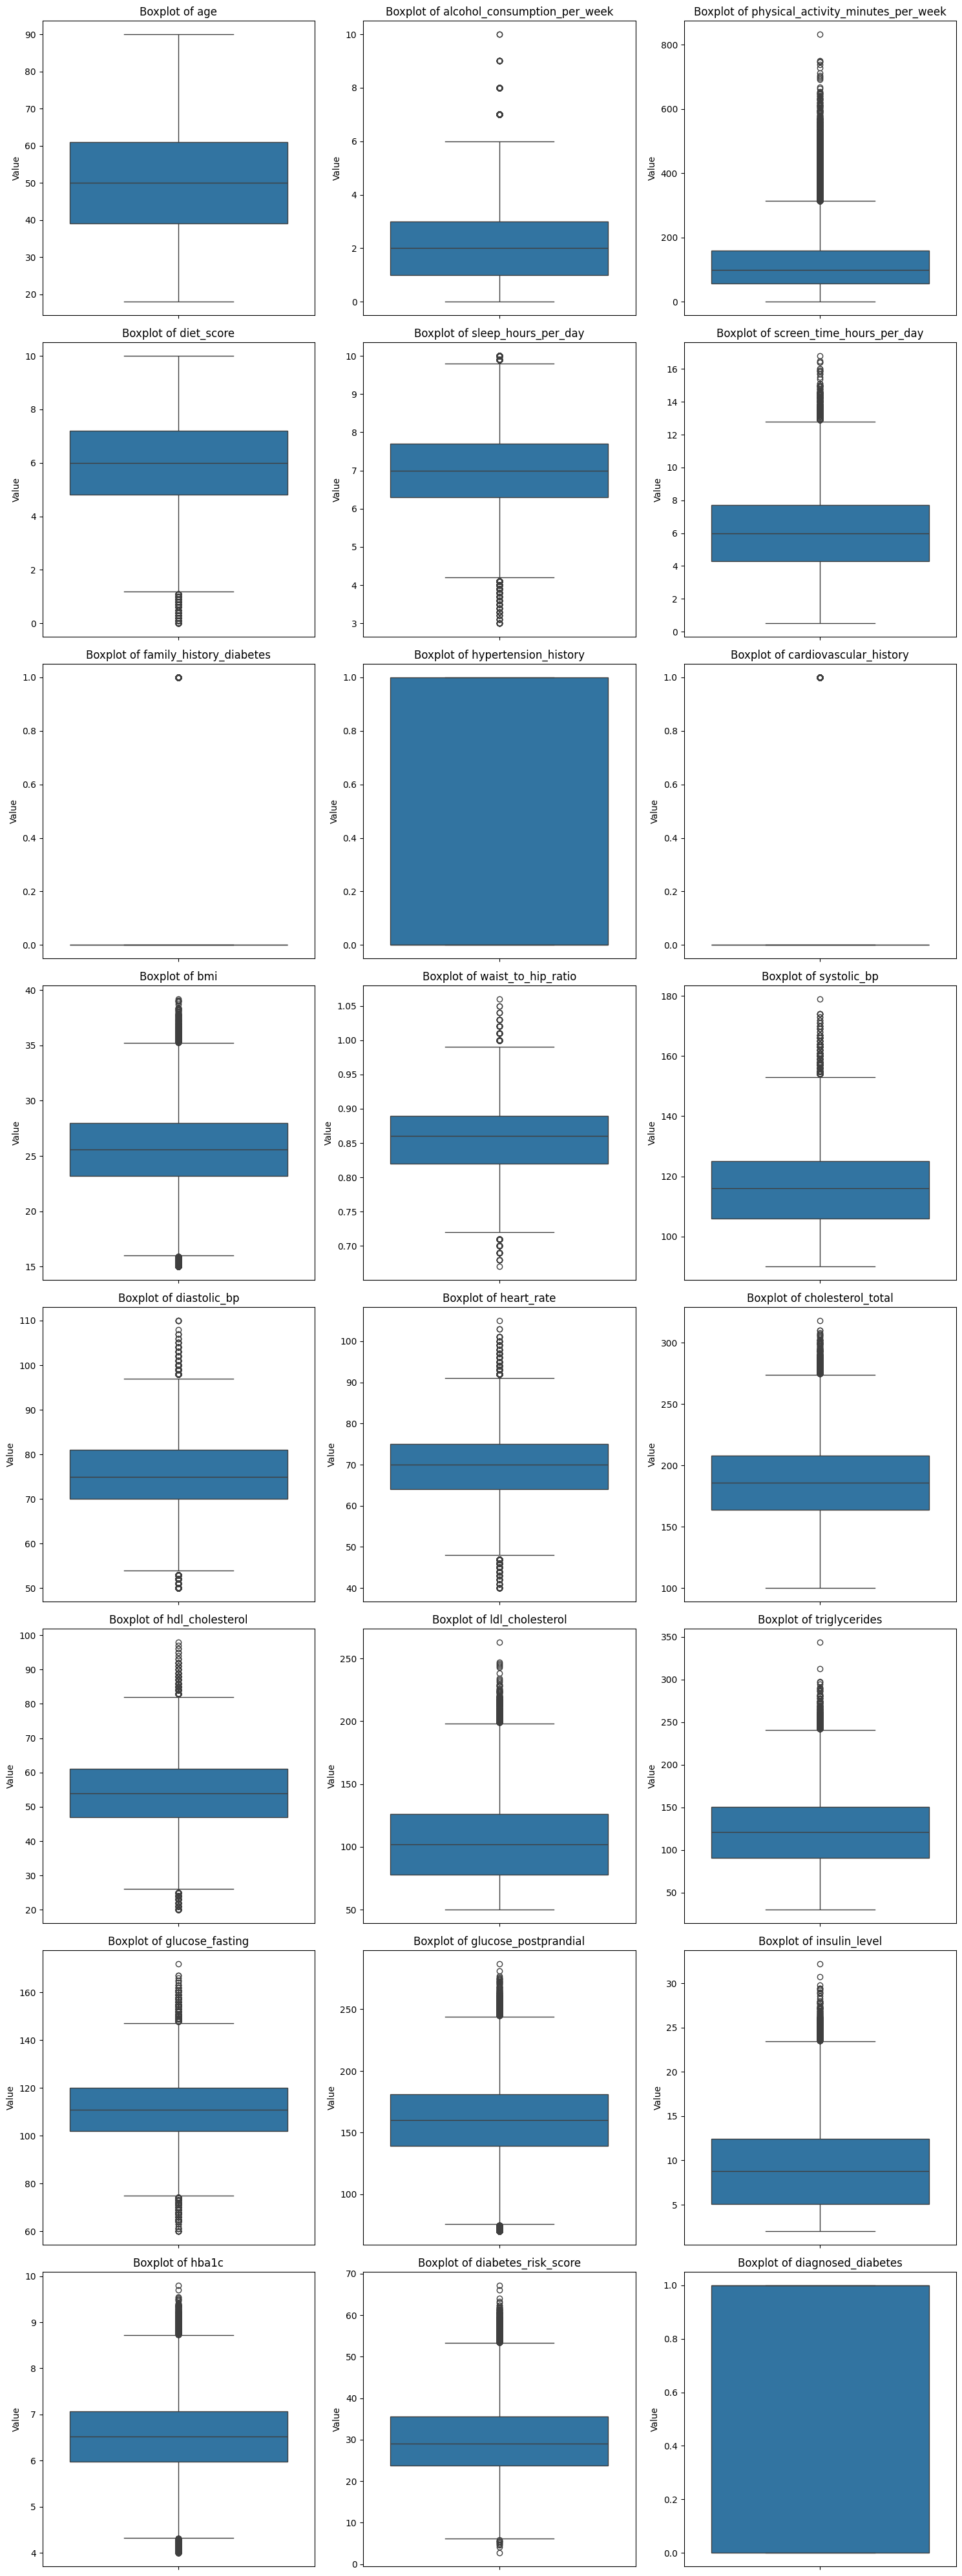


--- Outliers count per column ---
age: 0
alcohol_consumption_per_week: 458
physical_activity_minutes_per_week: 3199
diet_score: 337
sleep_hours_per_day: 900
screen_time_hours_per_day: 305
family_history_diabetes: 21941
hypertension_history: 0
cardiovascular_history: 7920
bmi: 744
waist_to_hip_ratio: 273
systolic_bp: 530
diastolic_bp: 731
heart_rate: 855
cholesterol_total: 309
hdl_cholesterol: 565
ldl_cholesterol: 349
triglycerides: 301
glucose_fasting: 745
glucose_postprandial: 634
insulin_level: 326
hba1c: 618
diabetes_risk_score: 914
diagnosed_diabetes: 0

✅ ทำการ Capping Outliers โดยละเว้นข้อมูลแบบ 0,1 เรียบร้อยแล้ว!


In [57]:
# 3. จัดการ Outliers ด้วยวิธี IQR (Capping)
# 3.1 พล็อต Boxplot เพื่อดูการกระจายตัวของข้อมูล
numeric_cols = df.select_dtypes(include=['number']).columns

num_cols = 3
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show() # หากต้องการบันทึกเป็นไฟล์ด้วย สามารถเพิ่ม plt.savefig('boxplots.png') ได้ครับ

# 3.2 ตรวจสอบและนับจำนวน Outliers ในแต่ละคอลัมน์
def check_outliers_iqr(df):
    outliers_report = {}
    numeric_cols = df.select_dtypes(include=['number']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        outliers_report[col] = outliers_count
    return outliers_report

outliers = check_outliers_iqr(df)
print("\n--- Outliers count per column ---")
for col, count in outliers.items():
    print(f"{col}: {count}")

def cap_outliers_iqr(df_in):
    df_out = df_in.copy()

    # 🌟 [จุดที่แก้] ระบุคอลัมน์ที่เป็น 0,1 หรือหมวดหมู่ ที่ไม่ต้องการให้ทำ Capping
    cols_to_exclude = [
        'diagnosed_diabetes',
        'family_history_diabetes',
        'hypertension_history',
        'cardiovascular_history'
    ]

    # ดึงมาเฉพาะคอลัมน์ตัวเลข และเตะคอลัมน์ยกเว้นทิ้งไป
    num_cols = df_out.select_dtypes(include=['number']).columns.drop(cols_to_exclude, errors='ignore')

    for col in num_cols:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_out[col] = np.where(df_out[col] < lower_bound, lower_bound, df_out[col])
        df_out[col] = np.where(df_out[col] > upper_bound, upper_bound, df_out[col])

    return df_out

df_cleaned = cap_outliers_iqr(df)
print("\n✅ ทำการ Capping Outliers โดยละเว้นข้อมูลแบบ 0,1 เรียบร้อยแล้ว!")

# **ขั้นที่ 4: วิเคราะห์ความสัมพันธ์เบื้องต้น (Correlation Matrix)**

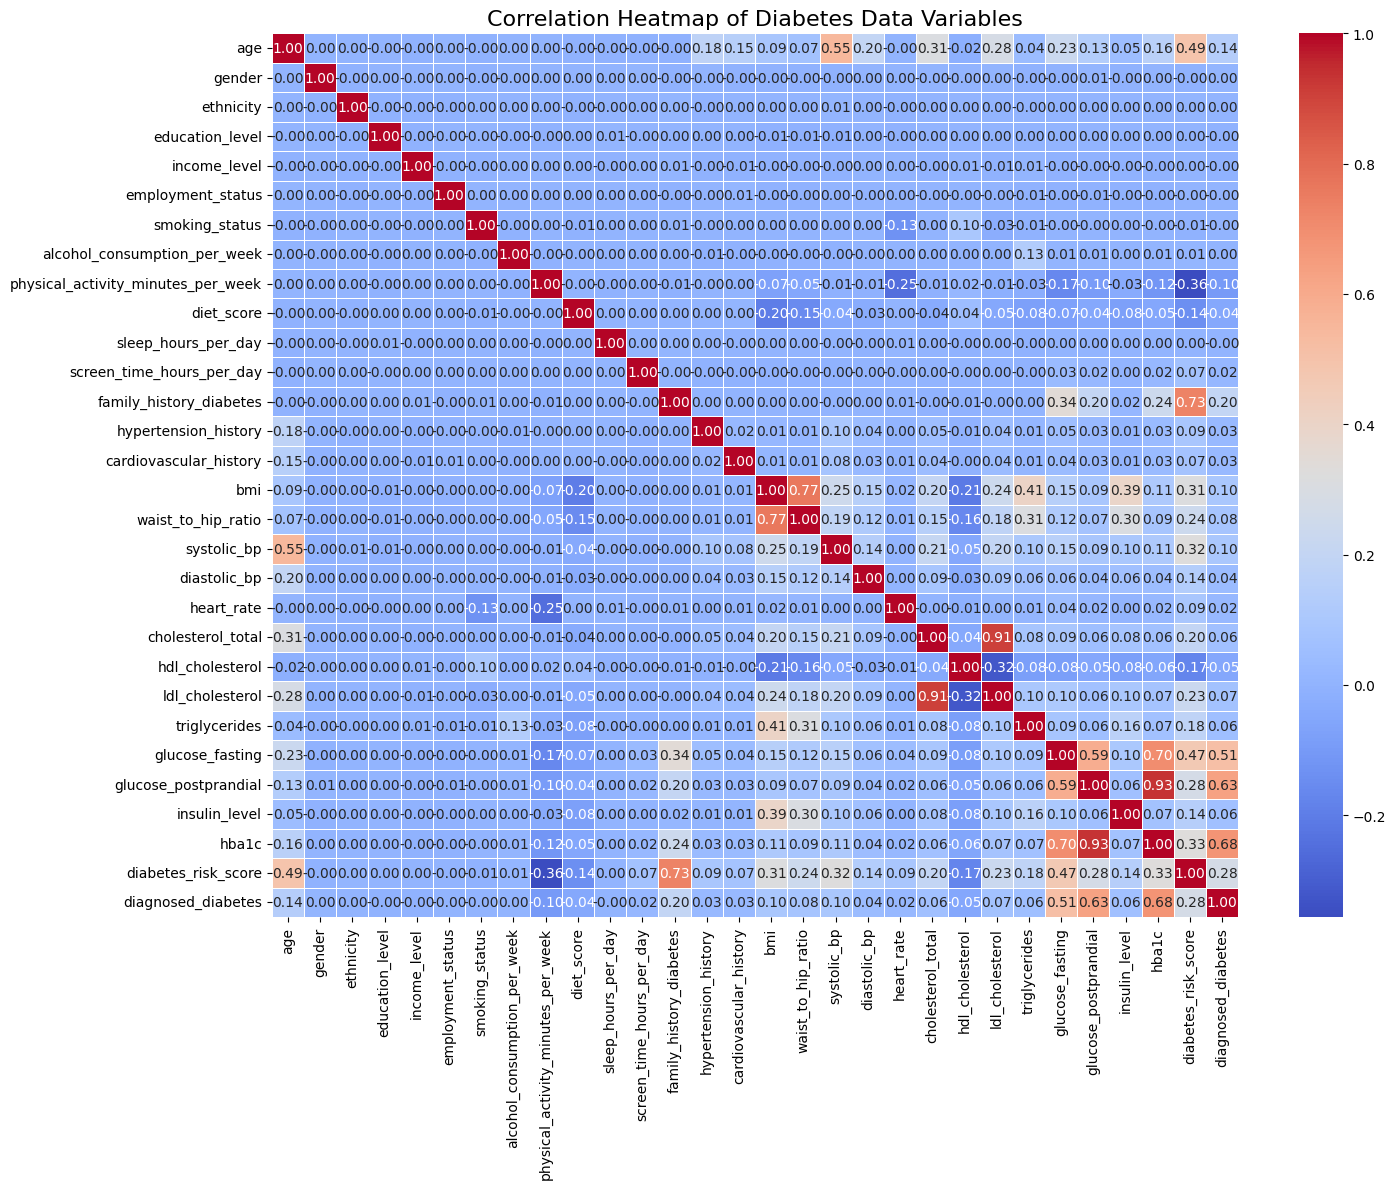

--- ความสัมพันธ์ของตัวแปรต่างๆ กับการเป็นเบาหวาน (Top 15) ---
diagnosed_diabetes         1.000000
hba1c                      0.681219
glucose_postprandial       0.631280
glucose_fasting            0.512568
diabetes_risk_score        0.277524
family_history_diabetes    0.197926
age                        0.137713
bmi                        0.097029
systolic_bp                0.095417
waist_to_hip_ratio         0.078898
ldl_cholesterol            0.067458
cholesterol_total          0.058087
insulin_level              0.057738
triglycerides              0.056185
diastolic_bp               0.035544
Name: diagnosed_diabetes, dtype: float64
--- ความไม่สัมพันธ์ของตัวแปรต่างๆ กับการเป็นเบาหวาน (Top 5) ---
education_level                      -0.004351
income_level                         -0.004539
diet_score                           -0.044327
hdl_cholesterol                      -0.051084
physical_activity_minutes_per_week   -0.101779
Name: diagnosed_diabetes, dtype: float64


In [58]:
# 4. พล็อต Heatmap ดูความสัมพันธ์ของทุกตัวแปร
# เตรียมข้อมูลและแปลงหมวดหมู่เป็นตัวเลขชั่วคราว (ใช้ df_cleaned จากขั้นที่ 3)
# ลบ diabetes_stage เพราะมันคือผลลัพธ์ที่เป็นหมวดหมู่ (เดี๋ยวจะกวนค่าของ diagnosed_diabetes)
df_corr = df_cleaned.drop(columns=['Patient_ID', 'risk_category', 'diabetes_stage'], errors='ignore')

for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# คำนวณ Correlation
corr_matrix = df_corr.corr()

# แสดง Heatmap
plt.figure(figsize=(15, 12)) # ขยายขนาดนิดหน่อยเพราะตัวแปรเบาหวานมีเยอะถึง 30 ตัว
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Diabetes Data Variables', fontsize=16)
plt.tight_layout()
plt.show() # หรือใช้ plt.savefig('correlation_heatmap.png') หากต้องการเซฟภาพ

# ดูความสัมพันธ์เฉพาะกับตัวแปรเป้าหมาย (diagnosed_diabetes)
print("--- ความสัมพันธ์ของตัวแปรต่างๆ กับการเป็นเบาหวาน (Top 15) ---")
print(corr_matrix['diagnosed_diabetes'].sort_values(ascending=False).head(15))
print("--- ความไม่สัมพันธ์ของตัวแปรต่างๆ กับการเป็นเบาหวาน (Top 5) ---")
print(corr_matrix['diagnosed_diabetes'].sort_values(ascending=False).tail(5))

# **4.5 การคัดกรองตัวแปร (Feature Selection Check)**

In [59]:
# เตรียมข้อมูล: ลบตัวแปรที่เป็นผลลัพธ์ออก (เช่น diabetes_stage ซึ่งเป็นคำตอบอยู่แล้ว)
df_check = df_cleaned.drop(columns=['diabetes_stage', 'Patient_ID'], errors='ignore')

# แปลงตัวอักษรเป็นตัวเลขเพื่อคำนวณความสัมพันธ์
for col in df_check.select_dtypes(include=['object']).columns:
    df_check[col] = df_check[col].astype('category').cat.codes

# คำนวณ Correlation ทั้งหมด
corr_features = df_check.corr().abs()
target_corr = df_check.corr()['diagnosed_diabetes'].abs()

# ------------------------------------------------------------------------------
# 🎯 ส่วนที่ 1: หาตัวแปรที่ไม่จำเป็น (ความสัมพันธ์กับ Target ต่ำมาก)
# ------------------------------------------------------------------------------
target_threshold = 0.05 # หากตัวแปรไหนสัมพันธ์กับเบาหวานน้อยกว่า 5% ถือว่าแทบไม่มีประโยชน์
useless_features = target_corr[target_corr < target_threshold].sort_values()

print("🗑️ 1. ตัวแปรที่แทบไม่มีผลต่อการเป็นเบาหวาน (Correlation < 0.05):")
if not useless_features.empty:
    for col, val in useless_features.items():
        print(f"   - {col}: {val:.4f}")
else:
    print("   - ไม่มีตัวแปรที่ต่ำกว่าเกณฑ์")
print("\n" + "-"*50 + "\n")

# ------------------------------------------------------------------------------
# 👯 ส่วนที่ 2: หาตัวแปรที่ทับซ้อนกันเอง (Multicollinearity)
# ------------------------------------------------------------------------------
overlap_threshold = 0.75 # หากตัวแปร 2 ตัวสัมพันธ์กันเองเกิน 75% ถือว่าซ้ำซ้อน
features_to_drop = set()

print("👯 2. คู่ตัวแปรที่ทับซ้อนกันเองสูง (Correlation > 0.75):")
found_overlap = False

for i in range(len(corr_features.columns)):
    for j in range(i):
        # ตรวจสอบค่า Correlation
        if corr_features.iloc[i, j] > overlap_threshold:
            col_i = corr_features.columns[i]
            col_j = corr_features.columns[j]

            # ข้ามการตรวจสอบถ้าไปชนกับ Target
            if col_i == 'diagnosed_diabetes' or col_j == 'diagnosed_diabetes':
                continue

            found_overlap = True
            # เปรียบเทียบว่าตัวไหนสัมพันธ์กับ Target (เบาหวาน) มากกว่ากัน
            if target_corr[col_i] > target_corr[col_j]:
                features_to_drop.add(col_j)
                print(f"⚠️ พบคู่ทับซ้อน: [{col_i}] กับ [{col_j}] (ความสัมพันธ์กันเอง: {corr_features.iloc[i, j]:.2f})")
                print(f"   ✅ แนะนำให้เก็บ: {col_i} (เพราะมีผลกับเบาหวาน {target_corr[col_i]:.2f})")
                print(f"   ❌ แนะนำให้ตัด: {col_j} (เพราะมีผลกับเบาหวาน {target_corr[col_j]:.2f})\n")
            else:
                features_to_drop.add(col_i)
                print(f"⚠️ พบคู่ทับซ้อน: [{col_i}] กับ [{col_j}] (ความสัมพันธ์กันเอง: {corr_features.iloc[i, j]:.2f})")
                print(f"   ✅ แนะนำให้เก็บ: {col_j} (เพราะมีผลกับเบาหวาน {target_corr[col_j]:.2f})")
                print(f"   ❌ แนะนำให้ตัด: {col_i} (เพราะมีผลกับเบาหวาน {target_corr[col_i]:.2f})\n")

if not found_overlap:
    print("   - ไม่พบคู่ที่ทับซ้อนกันเกินเกณฑ์")

🗑️ 1. ตัวแปรที่แทบไม่มีผลต่อการเป็นเบาหวาน (Correlation < 0.05):
   - sleep_hours_per_day: 0.0004
   - smoking_status: 0.0007
   - alcohol_consumption_per_week: 0.0011
   - employment_status: 0.0011
   - ethnicity: 0.0012
   - education_level: 0.0044
   - income_level: 0.0045
   - gender: 0.0046
   - screen_time_hours_per_day: 0.0183
   - heart_rate: 0.0229
   - hypertension_history: 0.0275
   - cardiovascular_history: 0.0298
   - diastolic_bp: 0.0355
   - diet_score: 0.0443

--------------------------------------------------

👯 2. คู่ตัวแปรที่ทับซ้อนกันเองสูง (Correlation > 0.75):
⚠️ พบคู่ทับซ้อน: [waist_to_hip_ratio] กับ [bmi] (ความสัมพันธ์กันเอง: 0.77)
   ✅ แนะนำให้เก็บ: bmi (เพราะมีผลกับเบาหวาน 0.10)
   ❌ แนะนำให้ตัด: waist_to_hip_ratio (เพราะมีผลกับเบาหวาน 0.08)

⚠️ พบคู่ทับซ้อน: [ldl_cholesterol] กับ [cholesterol_total] (ความสัมพันธ์กันเอง: 0.91)
   ✅ แนะนำให้เก็บ: ldl_cholesterol (เพราะมีผลกับเบาหวาน 0.07)
   ❌ แนะนำให้ตัด: cholesterol_total (เพราะมีผลกับเบาหวาน 0.06)

⚠️ พบคู่ท

# **ขั้นที่ 5: แบ่งกลุ่มตัวแปร (Feature Selection - Standard vs Advanced)**

แยกข้อมูลเป็น 2 โหมด คือแบบใช้ข้อมูลทั่วไป (Standard) และแบบมีผลเจาะเลือด (Advanced)

โดยตัดตัวแปรที่แทบไม่มีผลต่อการเป็นเบาหวาน และตัวแปรที่มีความสัมพันธ์ทับซ้อนกันเองสูง

✅ กำหนดตัวแปร Standard และ Advanced พร้อมแสดง Heatmap ทั้ง 2 กลุ่มเรียบร้อย!


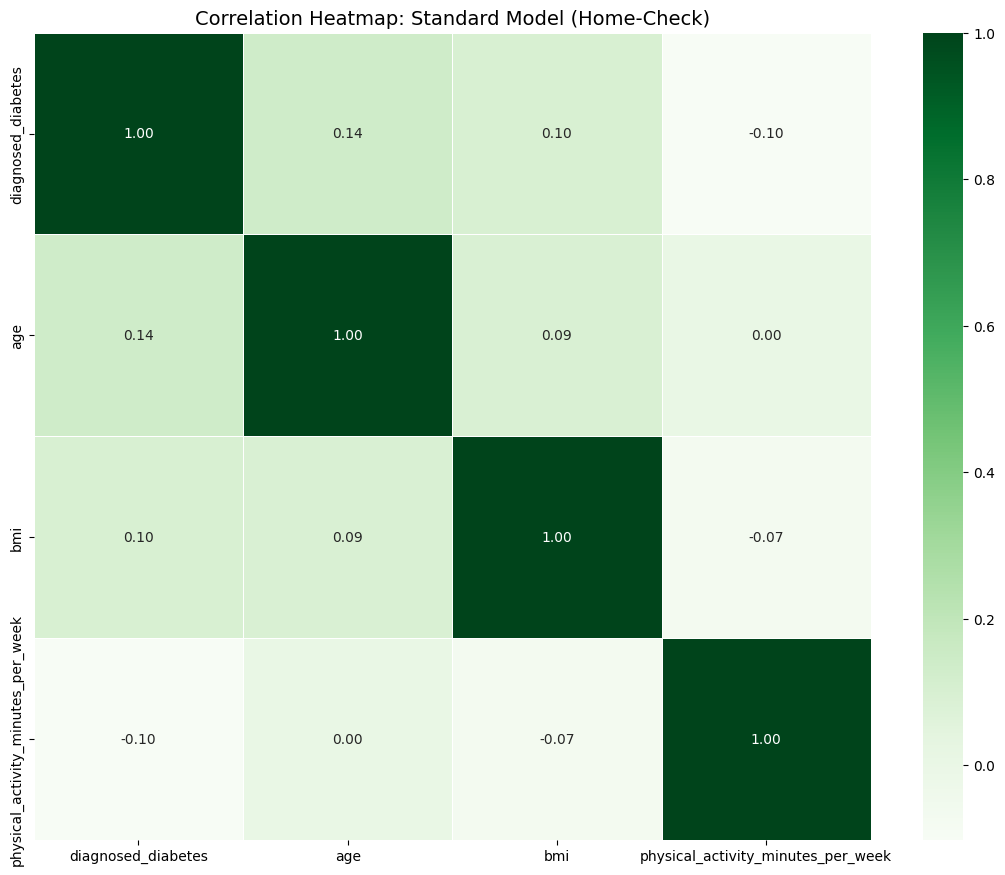

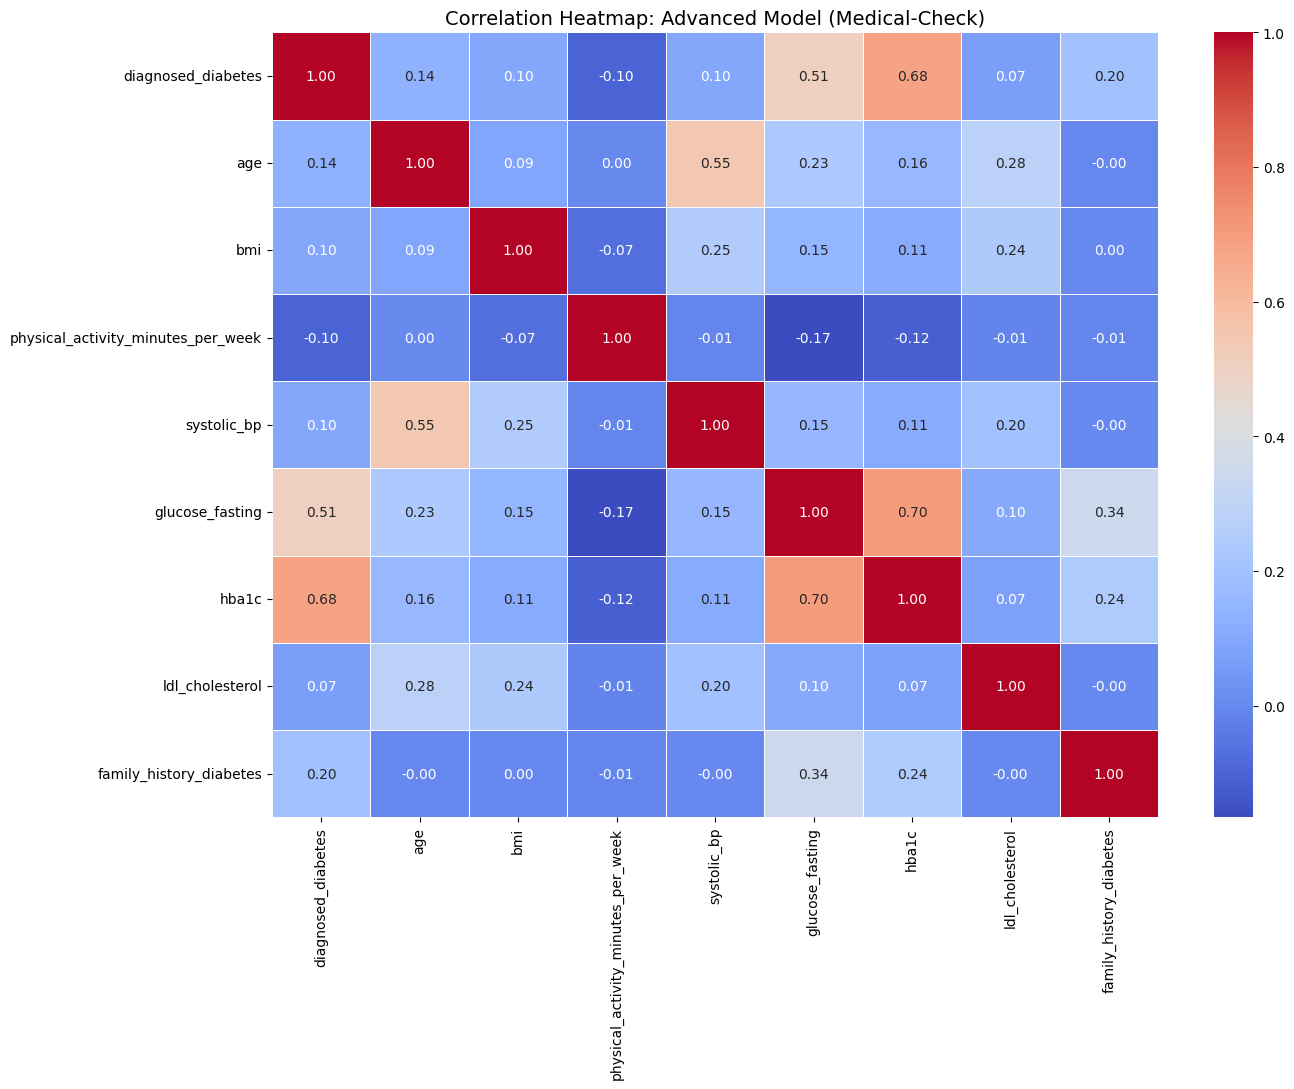

In [66]:
# 5.1 กำหนด Features
# กลุ่มที่ 1: ข้อมูลไลฟ์สไตล์และสุขภาพพื้นฐาน จากการทดสอบโมเดล (Ablation Study) พบว่าเมื่อตัวแปรมีน้อย (3-4 ตัว) ตัวแปร ประวัติครอบครัว จะกลายเป็น "ตัวชี้ขาด" (Deciding Factor) ที่มีน้ำหนักสูงมาก
base_features = [
    'age',
    'bmi',
    'physical_activity_minutes_per_week']

# กลุ่มที่ 2: ค่าผลตรวจทางห้องปฏิบัติการ (Lab)
lab_features = [
    'systolic_bp',
    'glucose_fasting',
    'hba1c',
    'ldl_cholesterol',
    'family_history_diabetes']

# รวมเป็นโหมด Advanced
all_features = base_features + lab_features
target_col = 'diagnosed_diabetes'

# 5.2 เตรียมข้อมูลสำหรับการพล็อต Heatmap (แปลงหมวดหมู่เป็นตัวเลขชั่วคราว)
# อิงจาก df_cleaned ในขั้นที่ 3
df_hm = df_cleaned.copy()
for col in df_hm.select_dtypes(include=['object']).columns:
    df_hm[col] = df_hm[col].astype('category').cat.codes

print("✅ กำหนดตัวแปร Standard และ Advanced พร้อมแสดง Heatmap ทั้ง 2 กลุ่มเรียบร้อย!")
# 5.3 พล็อต Heatmap: Standard Model (Home-Check)
plt.figure(figsize=(11, 9))
std_features_for_corr = [target_col] + base_features
sns.heatmap(df_hm[std_features_for_corr].corr(), annot=True, cmap='Greens', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Standard Model (Home-Check)', fontsize=14)
plt.tight_layout()
plt.show()

# 5.4 พล็อต Heatmap: Advanced Model (Medical-Check)
plt.figure(figsize=(14, 11))
adv_features_for_corr = [target_col] + all_features
sns.heatmap(df_hm[adv_features_for_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Advanced Model (Medical-Check)', fontsize=14)
plt.tight_layout()
plt.show()

# **ขั้นที่ 6: เทรนและเปรียบเทียบโมเดล (Model Training & Comparison)**

เอา 3 โมเดลมาเทรนเทียบกันทั้ง 2 โหมด พร้อมพล็อต Confusion Matrix แบบ 3x2

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score
import seaborn as sns
import pandas as pd
import joblib


>>> กำลังวิเคราะห์โมเดล: Support Vector Machine <<<

[ตัวอย่างการทำนายของ Support Vector Machine (Standard)]
 Actual  Predicted      Result
      0          1 ❌ Incorrect
      1          1   ✅ Correct
      0          1 ❌ Incorrect
      0          0   ✅ Correct
      1          1   ✅ Correct
--- พบจุดที่น่ากังวล (False Negative) จำนวน 1318 เคสใน Test Set ---
ตัวอย่างเคสที่หลุดตรวจ: 3 รายการแรก
 Actual  Predicted      Result
      1          0 ❌ Incorrect
      1          0 ❌ Incorrect
      1          0 ❌ Incorrect
------------------------------

[ตัวอย่างการทำนายของ Support Vector Machine (Advanced)]
 Actual  Predicted      Result
      0          0   ✅ Correct
      1          1   ✅ Correct
      0          0   ✅ Correct
      0          1 ❌ Incorrect
      1          0 ❌ Incorrect
--- พบจุดที่น่ากังวล (False Negative) จำนวน 1265 เคสใน Test Set ---
ตัวอย่างเคสที่หลุดตรวจ: 3 รายการแรก
 Actual  Predicted      Result
      1          0 ❌ Incorrect
      1          0 ❌ Incorrect
     

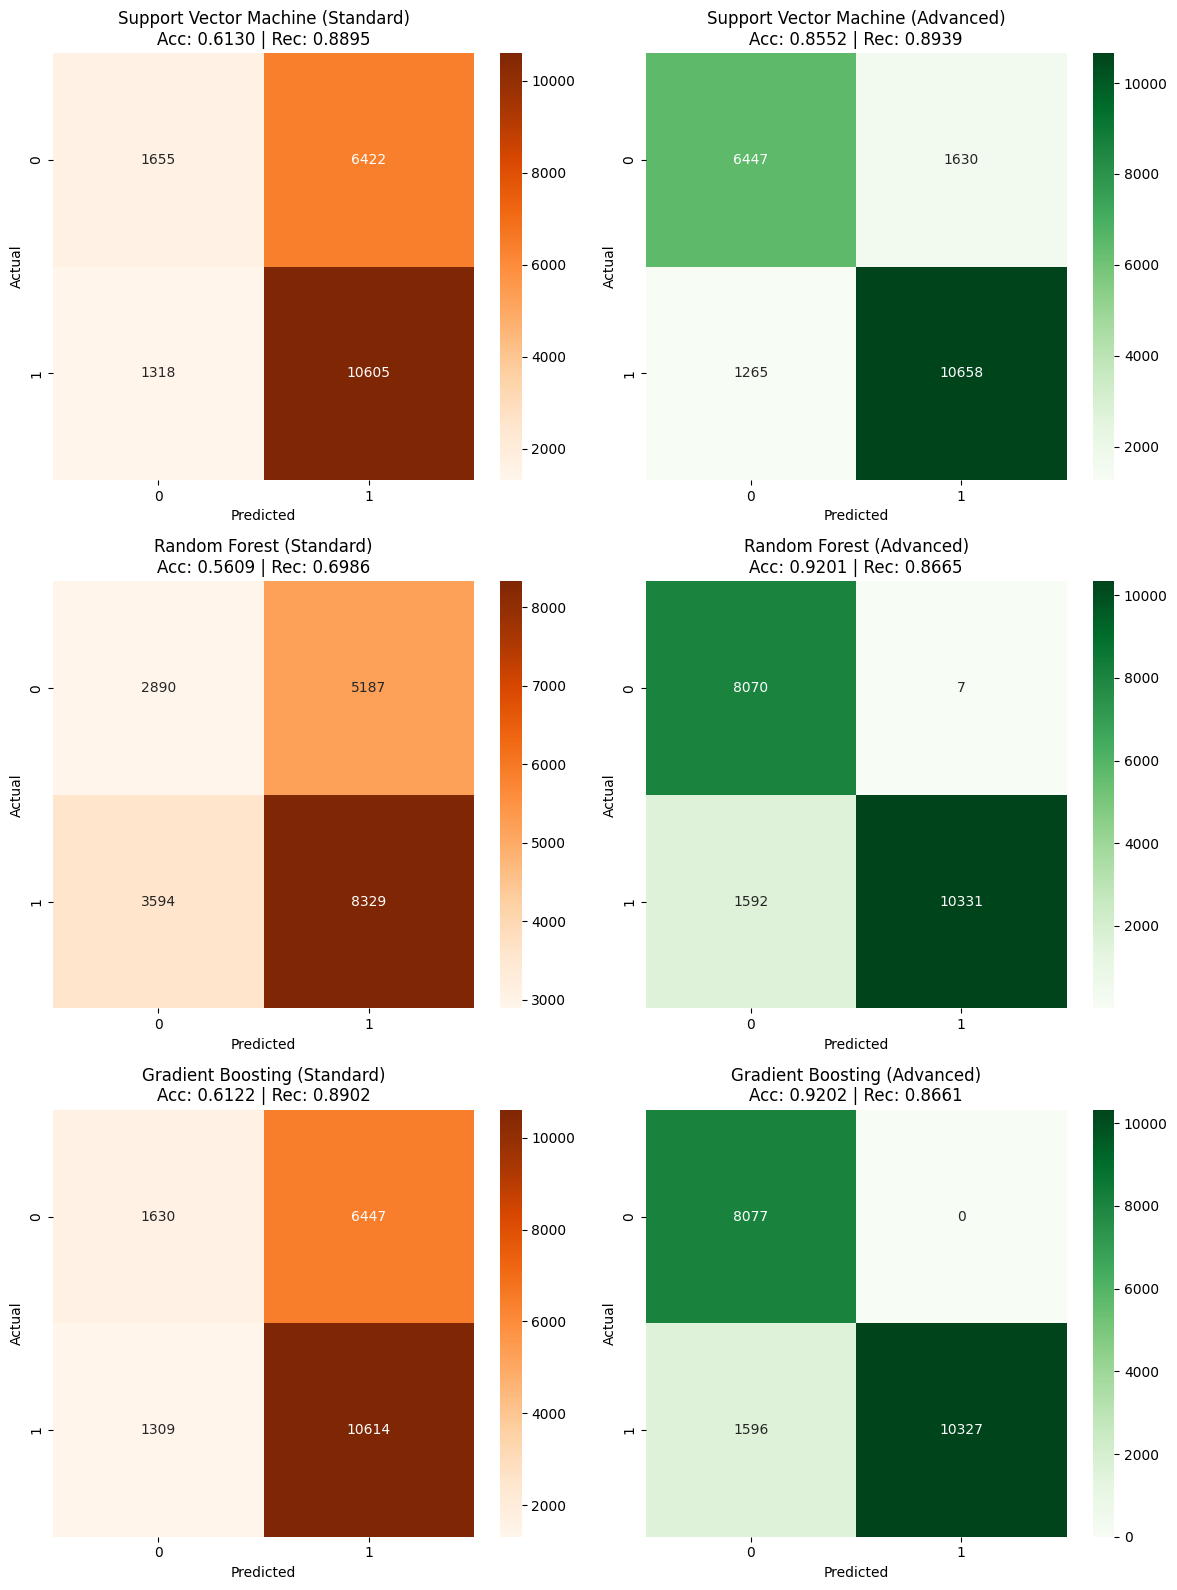


--- รายงานเปรียบเทียบประสิทธิภาพ: สรุปผลการทายถูก/ผิด ---
                 Model     Mode  Accuracy   Recall  F1-Score
Support Vector Machine Advanced   0.85525 0.893903  0.854668
     Gradient Boosting Standard   0.61220 0.890212  0.556135
Support Vector Machine Standard   0.61300 0.889457  0.557737
         Random Forest Advanced   0.92005 0.866477  0.920776
     Gradient Boosting Advanced   0.92020 0.866141  0.920926
         Random Forest Standard   0.56095 0.698566  0.550680

💡 สรุป: Support Vector Machine (Advanced) ทายคนเป็นเบาหวานได้แม่นที่สุด (Rec: 0.8939)


In [62]:
# 6.1 เตรียมข้อมูล
y = df_cleaned[target_col]
X_train_s, X_test_s, y_train, y_test = train_test_split(df_cleaned[base_features], y, test_size=0.2, random_state=42)
X_train_a, X_test_a, _, _ = train_test_split(df_cleaned[all_features], y, test_size=0.2, random_state=42)

# 6.2 ตัวจัดการข้อมูล (Preprocessor)
# เนื่องจากเราตัดตัวแปรหมวดหมู่ (เพศ, บุหรี่) ทิ้งไปหมดแล้ว ตอนนี้เหลือแต่ตัวเลขและ 0,1
# จึงใช้แค่ StandardScaler อย่างเดียวได้เลยครับ
prep_std = ColumnTransformer([('num', StandardScaler(), base_features)])
prep_adv = ColumnTransformer([('num', StandardScaler(), all_features)])

# 6.3 กำหนด 3 โมเดล
models = {
    "Support Vector Machine": LinearSVC(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# 6.4 วนลูปเทรนและพล็อต (เวอร์ชันเพิ่มการแสดงตัวอย่างถูก/ผิด)
results = []
fig, axes = plt.subplots(3, 2, figsize=(12, 16)) # เพิ่มความสูงเล็กน้อย

for i, (name, model) in enumerate(models.items()):
    print(f"\n>>> กำลังวิเคราะห์โมเดล: {name} <<<")

    # --- ฟังก์ชันช่วยแสดงตัวอย่างถูก/ผิด ---
    def show_prediction_samples(y_true, y_pred, mode_name, alg_name):
        df_samples = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})
        df_samples['Result'] = df_samples.apply(lambda x: '✅ Correct' if x['Actual'] == x['Predicted'] else '❌ Incorrect', axis=1)

        print(f"\n[ตัวอย่างการทำนายของ {alg_name} ({mode_name})]")
        print(df_samples.head(5).to_string(index=False))

        # เจาะลึกจุดที่ทายผิดแบบ False Negative (เป็นจริงแต่ทายว่าไม่เป็น)
        fn_samples = df_samples[(df_samples['Actual'] == 1) & (df_samples['Predicted'] == 0)]
        if not fn_samples.empty:
            print(f"--- พบจุดที่น่ากังวล (False Negative) จำนวน {len(fn_samples)} เคสใน Test Set ---")
            print(f"ตัวอย่างเคสที่หลุดตรวจ: {len(fn_samples.head(3))} รายการแรก")
            print(fn_samples.head(3).to_string(index=False))
        print("-" * 30)

    # --- ฝั่งซ้าย (Standard Mode) ---
    pipe_std = Pipeline([('prep', prep_std), ('model', model)])
    pipe_std.fit(X_train_s, y_train)
    y_pred_s = pipe_std.predict(X_test_s)

    acc_s = accuracy_score(y_test, y_pred_s)
    f1_s = f1_score(y_test, y_pred_s, average='weighted')
    rec_s = recall_score(y_test, y_pred_s)

    results.append({"Model": name, "Mode": "Standard", "Accuracy": acc_s, "Recall": rec_s, "F1-Score": f1_s})
    show_prediction_samples(y_test, y_pred_s, "Standard", name)

    sns.heatmap(confusion_matrix(y_test, y_pred_s), annot=True, fmt='d', cmap='Oranges', ax=axes[i, 0])
    axes[i, 0].set_title(f'{name} (Standard)\nAcc: {acc_s:.4f} | Rec: {rec_s:.4f}')
    axes[i, 0].set_xlabel('Predicted')
    axes[i, 0].set_ylabel('Actual')

    # --- ฝั่งขวา (Advanced Mode) ---
    pipe_adv = Pipeline([('prep', prep_adv), ('model', model)])
    pipe_adv.fit(X_train_a, y_train)
    y_pred_a = pipe_adv.predict(X_test_a)

    acc_a = accuracy_score(y_test, y_pred_a)
    f1_a = f1_score(y_test, y_pred_a, average='weighted')
    rec_a = recall_score(y_test, y_pred_a)

    results.append({"Model": name, "Mode": "Advanced", "Accuracy": acc_a, "Recall": rec_a, "F1-Score": f1_a})
    show_prediction_samples(y_test, y_pred_a, "Advanced", name)

    sns.heatmap(confusion_matrix(y_test, y_pred_a), annot=True, fmt='d', cmap='Greens', ax=axes[i, 1])
    axes[i, 1].set_title(f'{name} (Advanced)\nAcc: {acc_a:.4f} | Rec: {rec_a:.4f}')
    axes[i, 1].set_xlabel('Predicted')
    axes[i, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 6.5 ตารางสรุปผลและการวิเคราะห์เชิงลึก
results_df = pd.DataFrame(results).sort_values(by=['Recall'], ascending=False)
print("\n" + "="*70)
print("--- รายงานเปรียบเทียบประสิทธิภาพ: สรุปผลการทายถูก/ผิด ---")
print("="*70)
print(results_df.to_string(index=False))

best_recall_model = results_df.iloc[0]
print(f"\n💡 สรุป: {best_recall_model['Model']} ({best_recall_model['Mode']}) ทายคนเป็นเบาหวานได้แม่นที่สุด (Rec: {best_recall_model['Recall']:.4f})")

-----------------------


# **7. บันทึกโมเดลที่ดีที่สุด (Final Model Export)**

**Support Vector Machine และ Gradient Boosting** ทั้งสองโมเดลสามารถทำค่าrecallได้สูงสุดในAdvanced และ Standard โดยหากประเมินในเชิงการแพทย์ recallสำคัญที่สุด เพราะการทายร้ายเป็นดีถือว่าร้ายแรงกว่าการทายดีเป็นร้ายมาก


In [65]:
# --- 7. การบันทึกโมเดลแยก 2 โหมด (Dual Model: GB & SVM) ---

# 7.1 กำหนด Features (Standard 3 ตัว, Advanced 8 ตัว)
std_features = ['age', 'bmi', 'physical_activity_minutes_per_week']
adv_features = ['age', 'bmi', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'systolic_bp', 'glucose_fasting', 'hba1c', 'ldl_cholesterol']

# 7.2 เตรียม Library
from sklearn.ensemble import GradientBoostingClassifier # 💡 นำเข้า Gradient Boosting
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import joblib

# 7.3 เทรนและบันทึก Model 1: Standard Mode (ใช้ Gradient Boosting เพื่อ Recall สูงสุด)
prep_std = ColumnTransformer([('num', StandardScaler(), std_features)])
model_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

pipe_std = Pipeline([
    ('prep', prep_std),
    ('classifier', model_gb)
])
pipe_std.fit(df_cleaned[std_features], y)
joblib.dump(pipe_std, 'diabetes_model_standard.pkl')
print("✅ บันทึกโมเดล Standard สำเร็จ! (Gradient Boosting - High Recall)")

# 7.4 เทรนและบันทึก Model 2: Advanced Mode (ใช้ SVM เหมือนเดิม)
base_svm = LinearSVC(max_iter=2000, random_state=42)
calibrated_svm = CalibratedClassifierCV(base_svm)
prep_adv = ColumnTransformer([('num', StandardScaler(), adv_features)])

pipe_adv = Pipeline([
    ('prep', prep_adv),
    ('classifier', calibrated_svm)
])
pipe_adv.fit(df_cleaned[adv_features], y)
joblib.dump(pipe_adv, 'diabetes_model_advanced.pkl')
print("✅ บันทึกโมเดล Advanced สำเร็จ! (SVM - 8 Features)")

✅ บันทึกโมเดล Standard สำเร็จ! (Gradient Boosting - High Recall)
✅ บันทึกโมเดล Advanced สำเร็จ! (SVM - 8 Features)
